Part A
Least Squares MSE: 0.061399999999999934 R2: 0.9671024432061723
Poly3 MSE: 0.004828571428571388 R2: 0.9974128957197967
Better fit: Polynomial


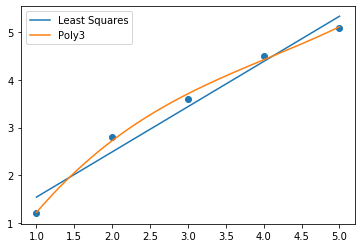

Part B 
Degree: 3 MSE: 0.004828571428571388 R2: 0.9974128957197967
Degree: 2 MSE: 0.009828571428571443 R2: 0.9947339415834915
Degree: 1 MSE: 0.06139999999999994 R2: 0.9671024432061723


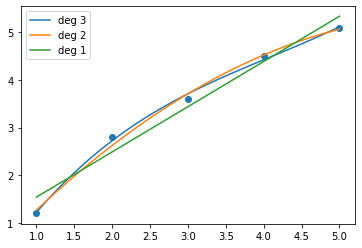

Part B 
Degree: 3 MSE: 0.004828571428571388 R2: 0.9974128957197967
Degree: 4 MSE: 3.2931984564582662e-28 R2: 1.0


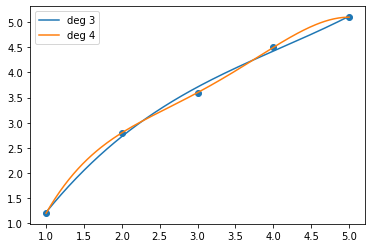

Part C
Degree: 1 MSE: 0.061399999999999934 R2: 0.9671024432061723
Degree: 2 MSE: 0.009828571428571386 R2: 0.9947339415834915
Degree: 3 MSE: 0.004828571428571465 R2: 0.9974128957197966
Degree: 4 MSE: 1.852738443524699e-28 R2: 1.0


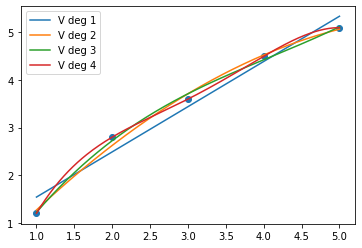

In [4]:
#A ,B, C 

import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt


X = np.array([1,2,3,4,5], dtype=float)
Y = np.array([1.2,2.8,3.6,4.5,5.1], dtype=float)


def mse(y, y_p):
    return np.mean((y - y_p)**2)

def r_sq(y, y_p):
    ss_tot = np.sum((y - np.mean(y))**2)
    ss_res = np.sum((y - y_p)**2)
    return 1 - ss_res/ss_tot


x_plot = np.linspace(X.min(), X.max(), 200)

#parta
A = np.vstack([X, np.ones(len(X))]).T
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
Y_ls = m*X + c

p3 = np.polyfit(X, Y, 3)
Y_poly3 = np.polyval(p3, X)

mse_ls = mse(Y, Y_ls)
mse_poly3 = mse(Y, Y_poly3)
r2_ls = r_sq(Y, Y_ls)
r2_poly3 = r_sq(Y, Y_poly3)

print("Part A")
print("Least Squares MSE:", mse_ls, "R2:", r2_ls)
print("Poly3 MSE:", mse_poly3, "R2:", r2_poly3)

better = "Polynomial" if mse_poly3 < mse_ls else "Least Squares"
print("Better fit:", better)

plt.scatter(X, Y)
plt.plot(x_plot, m*x_plot + c, label="Least Squares")
plt.plot(x_plot, np.polyval(p3, x_plot), label="Poly3")
plt.legend()
plt.show()

#partb
max_deg = min(10, len(X)-1)  

print("Part B ")
plt.scatter(X, Y)
for d in range(3, 0, -1):
    p = np.polyfit(X, Y, d)
    Y_pred = np.polyval(p, X)
    print("Degree:", d, "MSE:", mse(Y, Y_pred), "R2:", r_sq(Y, Y_pred))
    plt.plot(x_plot, np.polyval(p, x_plot), label=f"deg {d}")
plt.legend()
plt.show()

print("Part B ")
plt.scatter(X, Y)
for d in range(3, max_deg+1):
    p = np.polyfit(X, Y, d)
    Y_pred = np.polyval(p, X)
    print("Degree:", d, "MSE:", mse(Y, Y_pred), "R2:", r_sq(Y, Y_pred))
    plt.plot(x_plot, np.polyval(p, x_plot), label=f"deg {d}")
plt.legend()
plt.show()

# partc
print("Part C")
plt.scatter(X, Y)
for d in range(1, max_deg+1):
    V = np.vander(X, d+1)
    coef = np.linalg.lstsq(V, Y, rcond=None)[0]
    Y_v = V @ coef
    print("Degree:", d, "MSE:", mse(Y, Y_v), "R2:", r_sq(Y, Y_v))
    Vp = np.vander(x_plot, d+1)
    y_plot = Vp @ coef
    plt.plot(x_plot, y_plot, label=f"V deg {d}")

plt.legend()
plt.show()